# Preisvorhersage für Gebrauchtwagen mit linearer Regression

**Begleitskript zur Bachelorarbeit**

Autor: Semih Sönmez
Betreuer: Martin Dobler, BSc MSc
Datum: Mai 2026
Fachhochschule Vorarlberg

Dieses Skript umfasst die Datenaufbereitung, explorative Datenanalyse,
Modellentwicklung und Evaluation der in der Bachelorarbeit beschriebenen
Verfahren zur Preisvorhersage von Gebrauchtwagen.

## Inhalt
1. Imports und Datenladung
2. Datenaufbereitung
3. Feature Engineering
4. Explorative Datenanalyse
5. Modellentwicklung
   - Multiple lineare Regression
   - Entscheidungsbaum
6. Vollständige Gütemaße (MAE, RMSE, MAPE, R²)
7. Lineare Regression mit log-transformiertem Kilometerstand
8. 5-fold Cross-Validation
9. Alternative Datensplits
10. Feature Importance
11. Residualanalyse


## 1. Imports und Datenladung

In [1]:
# Bibliotheken
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score,
)

In [2]:
# Datensatz laden
# Hinweis: Die zugrunde liegenden Daten wurden im Rahmen dieser Arbeit
# mit ausdrücklicher Nutzungserlaubnis der Plattform DasWeltAuto.at erhoben.
# Eine Weitergabe der Daten ist gemäß dieser Vereinbarung nicht zulässig.
# Der Datensatz ist daher nicht im Abgabepaket enthalten.

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/WAuto/training-script-wAuto/audi_inserate.csv")
print(f"Anzahl Datensätze nach Import: {df.shape[0]}")
print(f"Anzahl Spalten: {df.shape[1]}")

Mounted at /content/drive
Anzahl Datensätze nach Import: 3241
Anzahl Spalten: 11


## 2. Feature Engineering: Modell extrahieren

Extraktion des Fahrzeugmodells aus dem Inserats-Titel mittels Regulärem Ausdruck.
Modelle, die nicht eindeutig zugeordnet werden können, werden als *Other* gekennzeichnet.

In [3]:
def extract_model(title):
    """Extrahiert das Audi-Modell (A1-A9, Q1-Q9, TT, R1-R9) aus dem Inserats-Titel."""
    if pd.isna(title):
        return None
    title = title.replace("\n", " ")
    match = re.search(r"Audi\s+(A\d|Q\d|TT|R\d)", title)
    return match.group(1) if match else "Other"

df["modell"] = df["titel"].apply(extract_model)

# Beispiel-Auszug
print("Auszug Modell-Zuordnung (erste 10 Einträge):")
print(df[["titel", "modell"]].head(10).to_string(index=False))

Auszug Modell-Zuordnung (erste 10 Einträge):
                                                      titel modell
                         Audi e-tron GT\n\nAudi S e-tron GT  Other
             Audi A3 Sportback\n\nAudi A3 Sportback 30 TFSI     A3
                        Audi A5 Avant\n\nAudi A5 Avant TFSI     A5
Audi A3 Sportback\n\nAudi A3 Sportback 30 TDI advanced ext.     A3
                          Audi SQ7\n\nAudi SQ7 TFSI quattro  Other
                         Audi Q2\n\nAudi Q2 35 TFSI admired     Q2
     Audi Q3 Sportback\n\nAudi Q3 Sportback 35 TFSI admired     Q3
     Audi A1 Sportback\n\nAudi A1 Sportback 25 TFSI intense     A1
     Audi A1 Sportback\n\nAudi A1 Sportback 30 TFSI intense     A1
                 Audi A5 Avant\n\nAudi A5 Avant TDI quattro     A5


## 3. Datenbereinigung

Entfernung unvollständiger Datensätze, Behandlung fehlender Werte, Ausschluss unplausibler Preise
sowie Reduktion seltener Modell-Ausprägungen zur Vermeidung von Overfitting.

In [4]:
# Datensätze ohne Zielvariable (Preis) entfernen
df = df.dropna(subset=["preis_eur"])

# Nur relevante Spalten behalten
df = df[[
    "preis_eur",
    "baujahr",
    "km",
    "leistung_ps",
    "getriebe",
    "antrieb",
    "modell",
]]

# Fehlende Werte in numerischen Variablen durch Median ersetzen
df["km"] = df["km"].fillna(df["km"].median())
df["leistung_ps"] = df["leistung_ps"].fillna(df["leistung_ps"].median())

# Datensätze ohne Baujahr entfernen
df = df.dropna(subset=["baujahr"])

# Unplausible Preise ausschließen (Ausreißer und fehlerhafte Inserate)
df = df[(df["preis_eur"] > 1000) & (df["preis_eur"] < 200000)]

# Seltene Modelle in Sammelkategorie 'Other' zusammenfassen
# (Reduziert Anzahl kategorialer Ausprägungen und beugt Overfitting vor)
top_models = df["modell"].value_counts().nlargest(10).index
df["modell"] = df["modell"].apply(lambda x: x if x in top_models else "Other")

print(f"Anzahl Datensätze nach Bereinigung: {df.shape[0]}")

Anzahl Datensätze nach Bereinigung: 3237


## 4. Berechnung abgeleiteter Variablen

Berechnung des Fahrzeugalters, der Kennzahl *Kilometer pro Jahr* sowie des
logarithmierten Kilometerstands für die explorative Analyse.

In [5]:
current_year = 2026
df["alter"] = current_year - df["baujahr"]
df = df[df["alter"] > 0]                       # nur sinnvolle Alterswerte
df["km_pro_jahr"] = df["km"] / df["alter"]
df["log_km"] = np.log1p(df["km"])              # log(1 + km) zur Vermeidung von log(0)

print(f"Anzahl Datensätze nach Feature Engineering: {df.shape[0]}")
print()
print("Statistik der numerischen Variablen:")
print(df[["preis_eur", "baujahr", "km", "leistung_ps", "alter", "km_pro_jahr"]].describe().round(2))

Anzahl Datensätze nach Feature Engineering: 2408

Statistik der numerischen Variablen:
       preis_eur  baujahr       km  leistung_ps    alter  km_pro_jahr
count    2408.00  2408.00  2408.00      2408.00  2408.00      2408.00
mean    46386.02  2023.35   406.74       205.83     2.65       250.54
std     23804.70     2.36   306.07       106.25     2.36       252.46
min      4500.00  2005.00     0.00        95.00     1.00         0.00
25%     28900.00  2022.00   142.75       116.00     1.00        45.71
50%     38220.00  2025.00   367.00       163.00     1.00       180.70
75%     59990.00  2025.00   657.75       245.00     4.00       350.25
max    199990.00  2025.00   999.00       630.00    21.00       999.00


## 5. Explorative Datenanalyse

Untersuchung der Zusammenhänge zwischen erklärenden Variablen und Fahrzeugpreis.

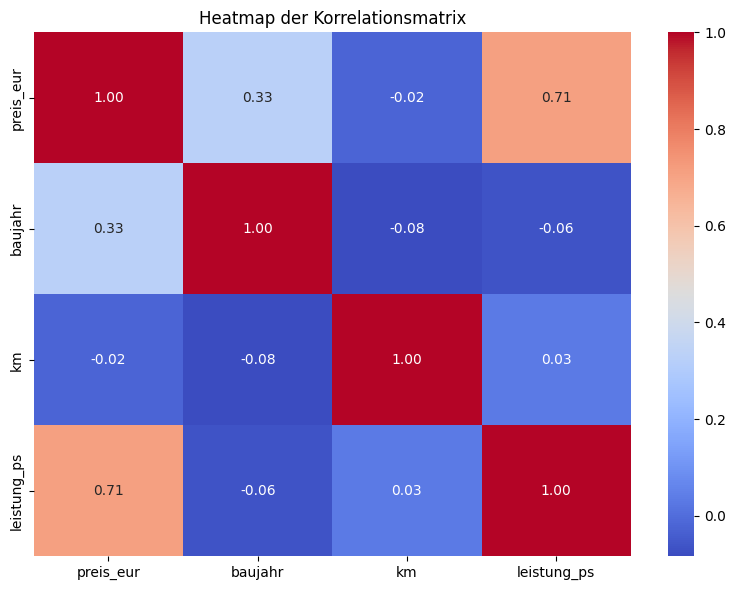

In [6]:
# 5.1 Heatmap der Korrelationsmatrix
corr = df[["preis_eur", "baujahr", "km", "leistung_ps"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap der Korrelationsmatrix")
plt.tight_layout()
plt.show()

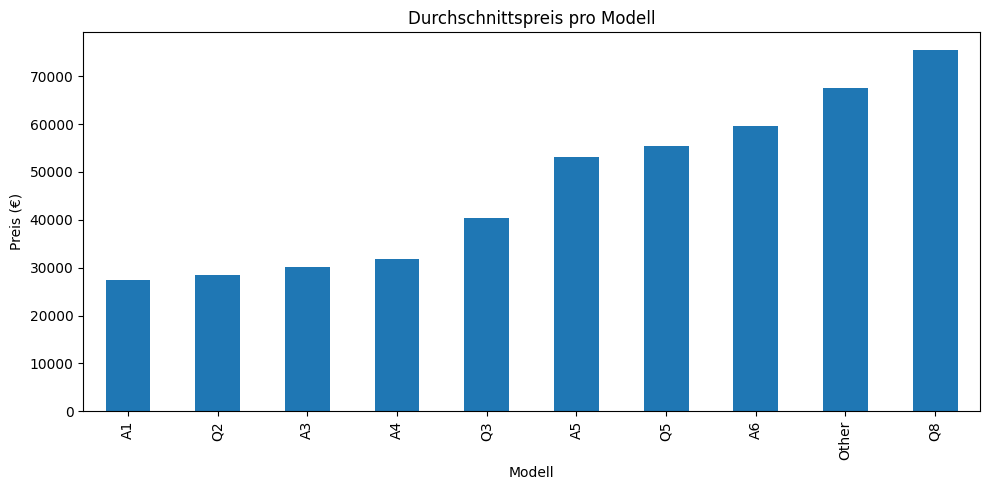

In [7]:
# 5.2 Durchschnittspreis je Fahrzeugmodell
plt.figure(figsize=(10, 5))
df.groupby("modell")["preis_eur"].mean().sort_values().plot(kind="bar")
plt.title("Durchschnittspreis pro Modell")
plt.ylabel("Preis (€)")
plt.xlabel("Modell")
plt.tight_layout()
plt.show()

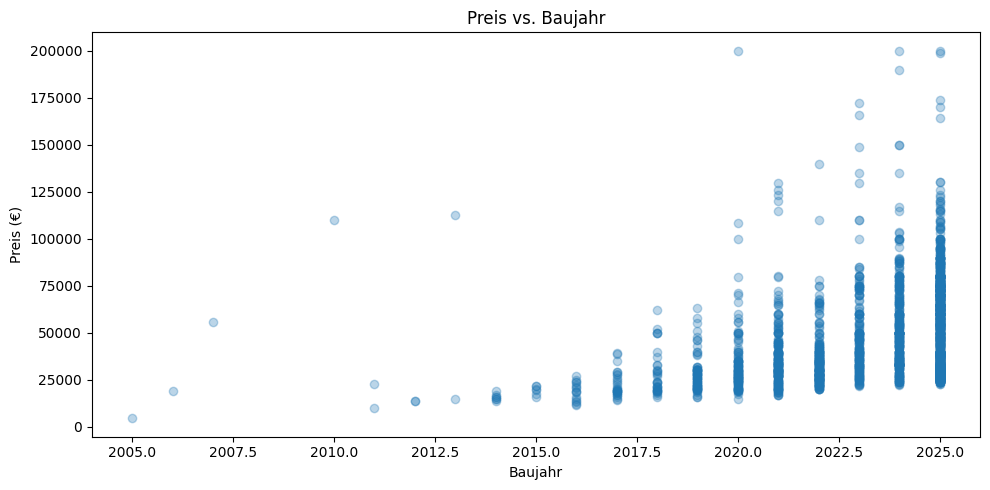

In [8]:
# 5.3 Preis und Baujahr
plt.figure(figsize=(10, 5))
plt.scatter(df["baujahr"], df["preis_eur"], alpha=0.3)
plt.title("Preis vs. Baujahr")
plt.xlabel("Baujahr")
plt.ylabel("Preis (€)")
plt.tight_layout()
plt.show()

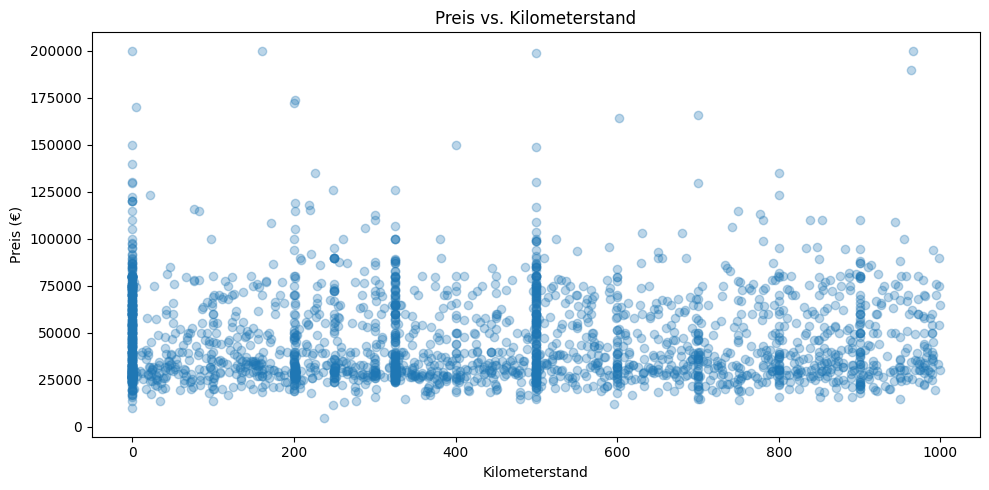

In [9]:
# 5.4 Preis und Kilometerstand
plt.figure(figsize=(10, 5))
plt.scatter(df["km"], df["preis_eur"], alpha=0.3)
plt.title("Preis vs. Kilometerstand")
plt.xlabel("Kilometerstand")
plt.ylabel("Preis (€)")
plt.tight_layout()
plt.show()

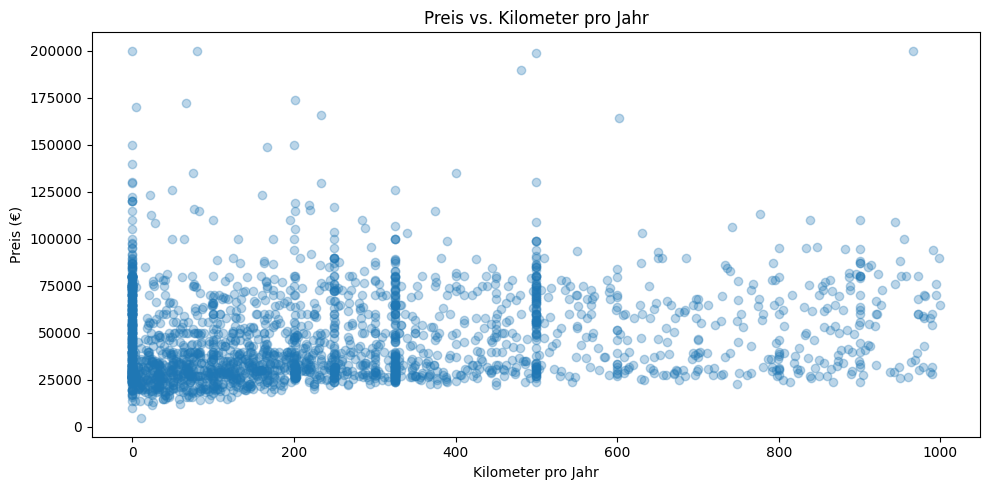

In [10]:
# 5.5 Preis und Kilometer pro Jahr
plt.figure(figsize=(10, 5))
plt.scatter(df["km_pro_jahr"], df["preis_eur"], alpha=0.3)
plt.title("Preis vs. Kilometer pro Jahr")
plt.xlabel("Kilometer pro Jahr")
plt.ylabel("Preis (€)")
plt.tight_layout()
plt.show()

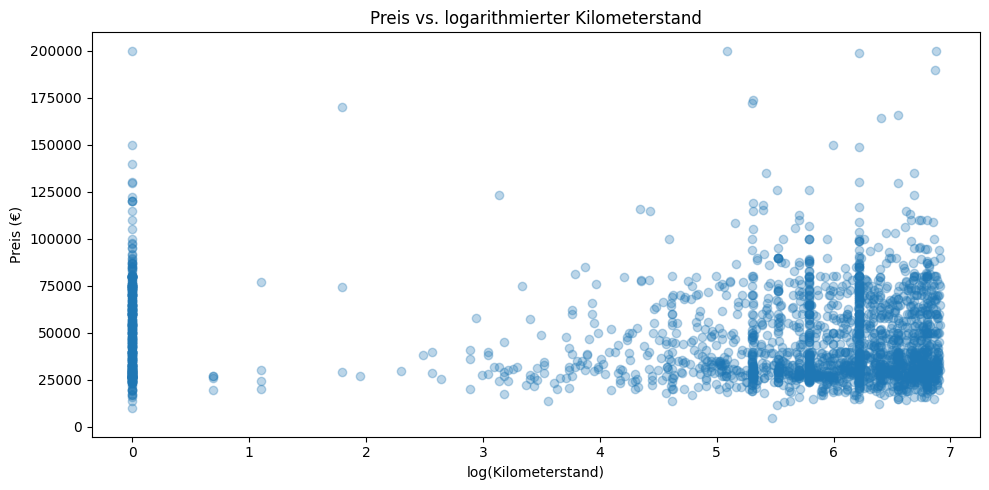

In [11]:
# 5.6 Preis und logarithmierter Kilometerstand
plt.figure(figsize=(10, 5))
plt.scatter(df["log_km"], df["preis_eur"], alpha=0.3)
plt.title("Preis vs. logarithmierter Kilometerstand")
plt.xlabel("log(Kilometerstand)")
plt.ylabel("Preis (€)")
plt.tight_layout()
plt.show()

## 6. Modellentwicklung

Aufteilung in Trainings- und Testdaten (80/20-Split) sowie One-Hot-Encoding der kategorialen Variablen.

Die Features umfassen die originalen Variablen (Baujahr, Kilometerstand, Leistung, Getriebe, Antrieb, Modell) sowie die abgeleiteten Variablen (Alter, *Kilometer pro Jahr*, log-Kilometerstand) aus der explorativen Datenanalyse.

In [12]:
# Features für die Hauptmodelle
# Abgeleitete Variablen aus der explorativen Analyse hier ausschließen
X = df.drop(columns=["preis_eur"])
y = df["preis_eur"]

# One-Hot-Encoding der kategorialen Variablen
X = pd.get_dummies(X, drop_first=True)
print(f"Anzahl Features nach One-Hot-Encoding: {X.shape[1]}")

# Trainings- / Testdaten (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Trainingsdaten: {len(X_train)}")
print(f"Testdaten: {len(X_test)}")

Anzahl Features nach One-Hot-Encoding: 18
Trainingsdaten: 1926
Testdaten: 482


### 6.1 Multiple lineare Regression

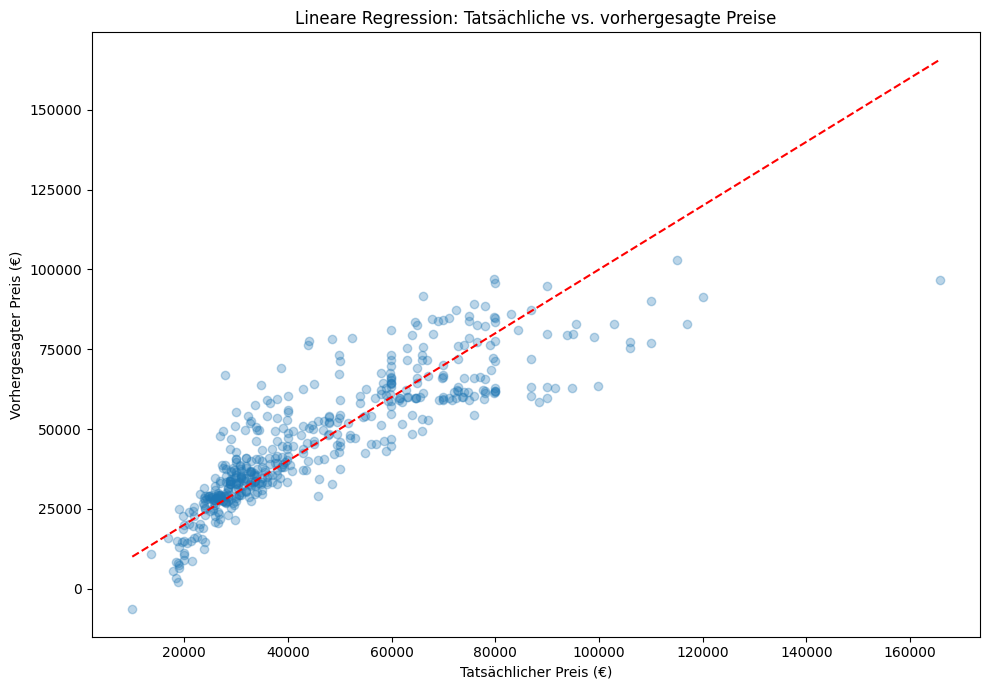

In [13]:
# Lineare Regression trainieren
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)

# Vergleich tatsächliche vs. vorhergesagte Preise
plt.figure(figsize=(10, 7))
plt.scatter(y_test, y_pred_lr, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Tatsächlicher Preis (€)")
plt.ylabel("Vorhergesagter Preis (€)")
plt.title("Lineare Regression: Tatsächliche vs. vorhergesagte Preise")
plt.tight_layout()
plt.show()

### 6.2 Entscheidungsbaum

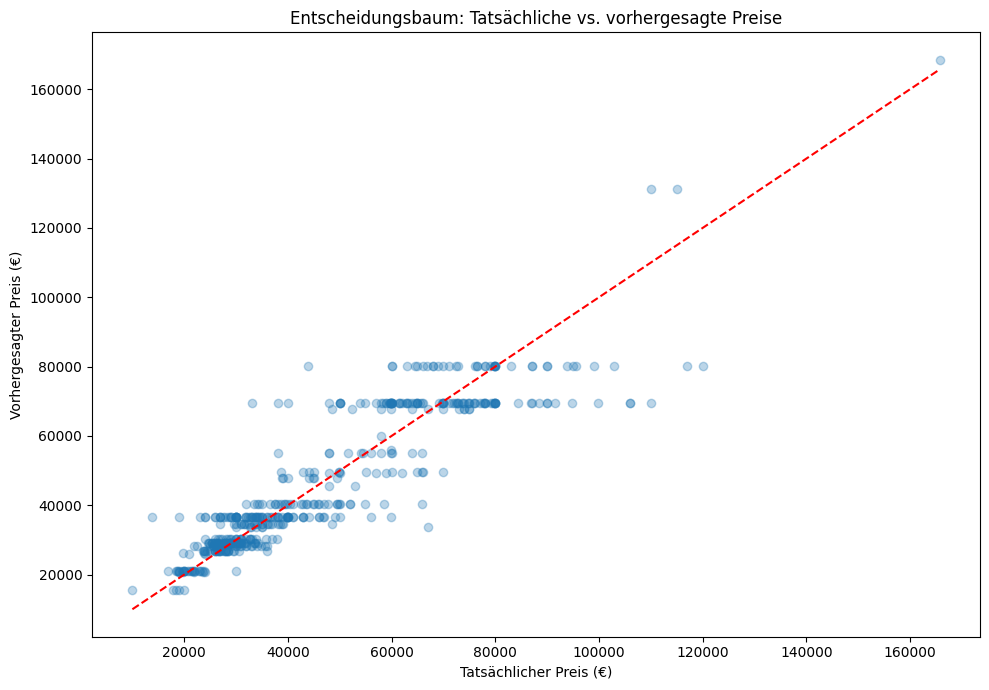

In [14]:
# Entscheidungsbaum trainieren (max_depth=5 zur Begrenzung von Overfitting)
model_dt = DecisionTreeRegressor(max_depth=5, random_state=42)
model_dt.fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_test)

# Vergleich tatsächliche vs. vorhergesagte Preise
plt.figure(figsize=(10, 7))
plt.scatter(y_test, y_pred_dt, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Tatsächlicher Preis (€)")
plt.ylabel("Vorhergesagter Preis (€)")
plt.title("Entscheidungsbaum: Tatsächliche vs. vorhergesagte Preise")
plt.tight_layout()
plt.show()

## 7. Vollständige Gütemaße

Berechnung der vier in der Arbeit (Kap. 4.5) genannten Bewertungskennzahlen:
MAE, RMSE, MAPE und R².

In [15]:
def alle_guetemasse(y_true, y_pred, modellname=""):
    """Berechnet MAE, RMSE, MAPE und R² für das angegebene Modell."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    r2   = r2_score(y_true, y_pred)

    print(f"\n--- {modellname} ---")
    print(f"MAE:  {mae:>10.2f} €")
    print(f"RMSE: {rmse:>10.2f} €")
    print(f"MAPE: {mape:>10.2f} %")
    print(f"R²:   {r2:>10.4f}")
    return {"Modell": modellname, "MAE": mae, "RMSE": rmse, "MAPE": mape, "R²": r2}

# Gütemaße für beide Hauptmodelle
ergebnisse = []
ergebnisse.append(alle_guetemasse(y_test, y_pred_lr, "Lineare Regression"))
ergebnisse.append(alle_guetemasse(y_test, y_pred_dt, "Entscheidungsbaum"))

# Vergleichstabelle
print("\n" + "="*60)
print("Vergleichstabelle der Gütemaße")
print("="*60)
vergleich = pd.DataFrame(ergebnisse)
print(vergleich.to_string(index=False))


--- Lineare Regression ---
MAE:     7859.91 €
RMSE:   11165.56 €
MAPE:      18.17 %
R²:       0.7450

--- Entscheidungsbaum ---
MAE:     6227.87 €
RMSE:    9253.97 €
MAPE:      13.51 %
R²:       0.8248

Vergleichstabelle der Gütemaße
            Modell         MAE         RMSE      MAPE       R²
Lineare Regression 7859.914233 11165.556102 18.165292 0.744979
 Entscheidungsbaum 6227.868489  9253.968751 13.512698 0.824825


## 8. Lineare Regression mit log-transformiertem Kilometerstand

Vergleich der Standard-LR mit einer Variante, in der die Variable `km` durch `log_km`
ersetzt wird (vgl. Begründung in Kap. 4.3 der Arbeit).

In [16]:
# Feature-Set mit log_km statt km
X_log = df.drop(columns=["preis_eur", "km"])
X_log = pd.get_dummies(X_log, drop_first=True)

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X_log, y, test_size=0.2, random_state=42
)

# Modell trainieren
model_lr_log = LinearRegression()
model_lr_log.fit(X_train_log, y_train_log)
y_pred_lr_log = model_lr_log.predict(X_test_log)

# Ergebnisse
ergebnis_log = alle_guetemasse(y_test_log, y_pred_lr_log, "Lineare Regression (log_km)")

# Direkter Vergleich
print("\n" + "="*60)
print("Vergleich: km vs. log_km in der linearen Regression")
print("="*60)
vergleich_log = pd.DataFrame([ergebnisse[0], ergebnis_log])
print(vergleich_log.to_string(index=False))


--- Lineare Regression (log_km) ---
MAE:     7865.12 €
RMSE:   11218.63 €
MAPE:      18.14 %
R²:       0.7425

Vergleich: km vs. log_km in der linearen Regression
                     Modell         MAE         RMSE      MAPE       R²
         Lineare Regression 7859.914233 11165.556102 18.165292 0.744979
Lineare Regression (log_km) 7865.118722 11218.629279 18.139752 0.742549


## 9. 5-fold Cross-Validation

Bewertung der Generalisierungsfähigkeit beider Hauptmodelle über fünf unabhängige Datenaufteilungen.

In [17]:
# Lineare Regression
scores_lr_r2  = cross_val_score(LinearRegression(), X, y, cv=5, scoring="r2")
scores_lr_mae = -cross_val_score(LinearRegression(), X, y, cv=5, scoring="neg_mean_absolute_error")

# Entscheidungsbaum
scores_dt_r2  = cross_val_score(
    DecisionTreeRegressor(max_depth=5, random_state=42), X, y, cv=5, scoring="r2"
)
scores_dt_mae = -cross_val_score(
    DecisionTreeRegressor(max_depth=5, random_state=42),
    X, y, cv=5, scoring="neg_mean_absolute_error"
)

# Ergebnistabelle
cv_df = pd.DataFrame({
    "Modell":    ["Lineare Regression", "Entscheidungsbaum"],
    "R² (Ø)":    [scores_lr_r2.mean(),  scores_dt_r2.mean()],
    "R² (Std)":  [scores_lr_r2.std(),   scores_dt_r2.std()],
    "MAE (Ø)":   [scores_lr_mae.mean(), scores_dt_mae.mean()],
    "MAE (Std)": [scores_lr_mae.std(),  scores_dt_mae.std()],
}).round(4)

print("5-fold Cross-Validation")
print("="*60)
print(cv_df.to_string(index=False))

5-fold Cross-Validation
            Modell  R² (Ø)  R² (Std)   MAE (Ø)  MAE (Std)
Lineare Regression  0.7176    0.0174 8006.9776   244.9445
 Entscheidungsbaum  0.7979    0.0239 7031.0511    60.5320


## 10. Alternative Datensplits

Untersuchung der Modellrobustheit auf zwei Teildatensätzen:
- Variante A: ohne Fahrzeuge der Q-Reihe
- Variante B: nur Fahrzeuge mit Baujahr ≥ 2020

In [18]:
def trainiere_und_bewerte(df_subset, beschreibung):
    """Trainiert LR und DT auf einem Subset des Datensatzes und gibt Gütemaße zurück."""
    if len(df_subset) < 50:
        print(f"\n[{beschreibung}] Zu wenige Datensätze ({len(df_subset)}).")
        return None

    # Gleiche Feature-Auswahl wie beim Hauptmodell
    X_sub = df_subset.drop("preis_eur", axis=1)
    y_sub = df_subset["preis_eur"]
    X_sub = pd.get_dummies(X_sub, drop_first=True)

    X_tr, X_te, y_tr, y_te = train_test_split(X_sub, y_sub, test_size=0.2, random_state=42)

    lr = LinearRegression().fit(X_tr, y_tr)
    dt = DecisionTreeRegressor(max_depth=5, random_state=42).fit(X_tr, y_tr)

    print(f"\n{'='*60}")
    print(f"[{beschreibung}] — n = {len(df_subset)}")
    print(f"{'='*60}")
    erg_lr = alle_guetemasse(y_te, lr.predict(X_te), "Lineare Regression")
    erg_dt = alle_guetemasse(y_te, dt.predict(X_te), "Entscheidungsbaum")
    erg_lr.update({"Datensatz": beschreibung, "n": len(df_subset)})
    erg_dt.update({"Datensatz": beschreibung, "n": len(df_subset)})
    return [erg_lr, erg_dt]

# Variante A: ohne Q-Reihe
df_ohne_q = df[~df["modell"].str.startswith("Q")].copy()
erg_a = trainiere_und_bewerte(df_ohne_q, "A: ohne Q-Reihe")

# Variante B: nur Baujahr >= 2020
df_neu = df[df["baujahr"] >= 2020].copy()
erg_b = trainiere_und_bewerte(df_neu, "B: Baujahr >= 2020")

# Gesamtübersicht
alle_ergebnisse = []
alle_ergebnisse.append({**ergebnisse[0], "Datensatz": "Vollständig", "n": len(df)})
alle_ergebnisse.append({**ergebnisse[1], "Datensatz": "Vollständig", "n": len(df)})
for erg in [erg_a, erg_b]:
    if erg:
        alle_ergebnisse.extend(erg)

print("\n" + "="*60)
print("Gesamtübersicht alternative Datensplits")
print("="*60)
uebersicht = pd.DataFrame(alle_ergebnisse)
uebersicht = uebersicht[["Datensatz", "n", "Modell", "MAE", "RMSE", "MAPE", "R²"]]
print(uebersicht.to_string(index=False))


[A: ohne Q-Reihe] — n = 1728

--- Lineare Regression ---
MAE:     8273.13 €
RMSE:   12152.49 €
MAPE:      20.65 %
R²:       0.7284

--- Entscheidungsbaum ---
MAE:     7071.03 €
RMSE:   10580.76 €
MAPE:      16.97 %
R²:       0.7941

[B: Baujahr >= 2020] — n = 2238

--- Lineare Regression ---
MAE:     8069.98 €
RMSE:   13689.44 €
MAPE:      17.01 %
R²:       0.7096

--- Entscheidungsbaum ---
MAE:     7294.19 €
RMSE:   11920.53 €
MAPE:      14.30 %
R²:       0.7798

Gesamtübersicht alternative Datensplits
         Datensatz    n             Modell         MAE         RMSE      MAPE       R²
       Vollständig 2408 Lineare Regression 7859.914233 11165.556102 18.165292 0.744979
       Vollständig 2408  Entscheidungsbaum 6227.868489  9253.968751 13.512698 0.824825
   A: ohne Q-Reihe 1728 Lineare Regression 8273.133380 12152.485353 20.647361 0.728437
   A: ohne Q-Reihe 1728  Entscheidungsbaum 7071.034934 10580.764366 16.973246 0.794139
B: Baujahr >= 2020 2238 Lineare Regression 8069.978767 

## 11. Feature Importance des Entscheidungsbaums

Bewertung der Bedeutung einzelner Variablen für die Modellentscheidungen.

Top 15 Features nach Importance:
                Feature  Importance
   antrieb_Frontantrieb    0.424929
            leistung_ps    0.307608
                baujahr    0.242461
            km_pro_jahr    0.008870
              modell_Q8    0.007713
                  alter    0.005216
              modell_Q3    0.002459
getriebe_Schaltgetriebe    0.000701
                     km    0.000043
                 log_km    0.000000
              modell_A3    0.000000
    antrieb_Heckantrieb    0.000000
              modell_A4    0.000000
              modell_A5    0.000000
           modell_Other    0.000000


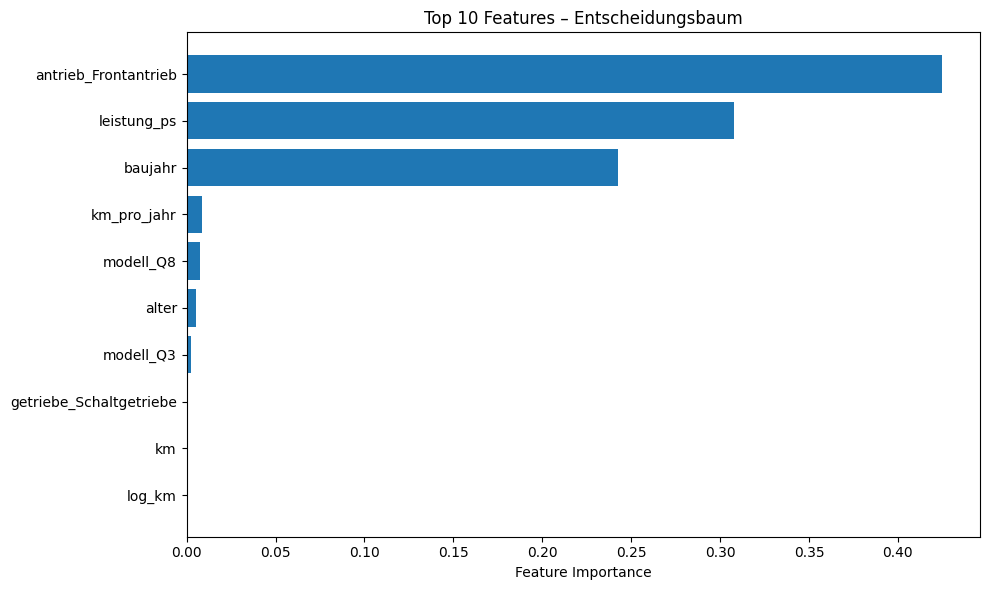

In [19]:
# Feature Importance berechnen
importance_df = pd.DataFrame({
    "Feature":    X.columns,
    "Importance": model_dt.feature_importances_,
}).sort_values(by="Importance", ascending=False)

print("Top 15 Features nach Importance:")
print(importance_df.head(15).to_string(index=False))

# Top-10 visualisieren
plt.figure(figsize=(10, 6))
top10 = importance_df.head(10)
plt.barh(top10["Feature"][::-1], top10["Importance"][::-1])
plt.xlabel("Feature Importance")
plt.title("Top 10 Features – Entscheidungsbaum")
plt.tight_layout()
plt.show()

## 12. Residualanalyse

Untersuchung der Verteilung der Vorhersagefehler beider Modelle.

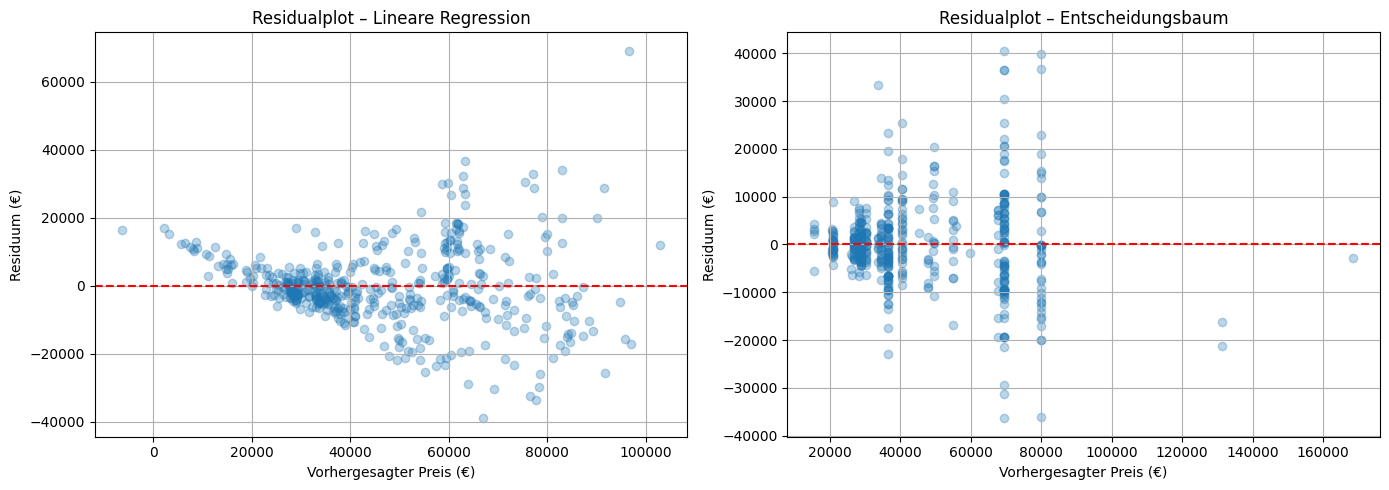


--- Residuen Lineare Regression ---
Mittelwert:              -335.70 €
Standardabweichung:     11172.10 €
Minimum:               -38976.54 €
Maximum:                69062.01 €

--- Residuen Entscheidungsbaum ---
Mittelwert:                74.90 €
Standardabweichung:      9263.28 €
Minimum:               -36398.09 €
Maximum:                40561.91 €


In [20]:
# Residuen berechnen
residuen_lr = y_test - y_pred_lr
residuen_dt = y_test - y_pred_dt

# Plot beider Residualverteilungen
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_lr, residuen_lr, alpha=0.3)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Vorhergesagter Preis (€)")
axes[0].set_ylabel("Residuum (€)")
axes[0].set_title("Residualplot – Lineare Regression")
axes[0].grid(True)

axes[1].scatter(y_pred_dt, residuen_dt, alpha=0.3)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Vorhergesagter Preis (€)")
axes[1].set_ylabel("Residuum (€)")
axes[1].set_title("Residualplot – Entscheidungsbaum")
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Statistische Kennzahlen der Residuen
print("\n--- Residuen Lineare Regression ---")
print(f"Mittelwert:         {residuen_lr.mean():>12.2f} €")
print(f"Standardabweichung: {residuen_lr.std():>12.2f} €")
print(f"Minimum:            {residuen_lr.min():>12.2f} €")
print(f"Maximum:            {residuen_lr.max():>12.2f} €")

print("\n--- Residuen Entscheidungsbaum ---")
print(f"Mittelwert:         {residuen_dt.mean():>12.2f} €")
print(f"Standardabweichung: {residuen_dt.std():>12.2f} €")
print(f"Minimum:            {residuen_dt.min():>12.2f} €")
print(f"Maximum:            {residuen_dt.max():>12.2f} €")